# AG-HYPOPT · Trial 11

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_11. Ten trials recorded; target plateau (seven samples in 0.0803-0.0890, best
exp6 0.0803 @ h_f 4.0) is flat within noise; edges degrade; sim 0.1249 and power 0.1541 rules are clearly
worse. A weak within-SE hint from trial_09 (h_f held at 4.0, h_s raised to 7.57 -> 0.0859 vs exp6's 0.0803
at h_s 3.675) is that a smaller sigma coefficient is slightly better, but no plateau trial has yet used a low
h_s (all campaign h_s >= 5.3 except exp6's 3.675).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_11'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (10/5 trials)
ID |     ei | params
 1 | 0.4480 | {"bandwidth_rule": "target", "h_f_scale": 5.350965239028333, "h_s_scale": 2.627186930352015}
 2 | 0.5076 | {"bandwidth_rule": "power", "h_f_scale": 2.427513443392278, "h_s_scale": 4.0970577940415}
 3 | 0.6251 | {"bandwidth_rule": "target", "h_f_scale": 5.060578865329001, "h_s_scale": 2.5176488015365086}
 4 | 2.0665 | {"bandwidth_rule": "sim", "h_f_scale": 3.461450098500478, "h_s_scale": 6.4107471672211815}
 5 | 0.9369 | {"bandwidth_rule": "power", "h_f_scale": 7.091033991517506, "h_s_scale": 5.930931435366157}
 6 | 0.7614 | {"bandwidth_rule": "target", "h_f_scale": 9.824229521563318, "h_s_scale": 5.8178884386461895}
 7 | 0.8498 | {"bandwidth_rule": "target", "h_f_scale": 1.9142869750876663, "h_s_scale": 6.4395535635041075}
 8 | 1.7238 | {"bandwidth_rule": "target", "h_f_scale": 4.188057662237812, "h_s_scale": 5.041349695395455}
 9 |      - | {"bandwidth_rule": "sim", "h_f_scale": 3.2084584957734124, "h_s_scale": 4.8032266

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The highest-EI proposal is #4 (sim, 3.461/6.411, EI 2.067), but `sim` is a rule the campaign has already
shown to be clearly worse (0.1249) than target, so following EI into it is not sensible. Among target
candidates, the notable ones are #1 (target 5.351/2.627) and #3 (target 5.061/2.518): these are the first
proposals with a genuinely LOW h_s (~2.5), which is exactly the direction the weak trial_09 signal points
(smaller sigma coefficient better) and a corner no campaign trial has occupied. The other target
candidates sit at h_s 5-11 (plateau, already sampled) or at the bad h_f edges (1.91, 9.82).

Candidate #3 is the best pick: target rule, h_f 5.06 (inside the plateau), h_s 2.52 (new low-h_s corner). It
tests the one remaining hypothesis cheaply.

I choose candidate 3 (target, h_f_scale 5.061, h_s_scale 2.518).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'target', 'h_f_scale': 5.060578865329001, 'h_s_scale': 2.5176488015365086}
Running  1nW Trans05 ... 

μ 9.39 -> 5.45 | γ 8.5 -> 3.20 | NLL 0.35


Running  1nW Trans20 ... 

μ 17.32 -> 24.94 | γ 8.5 -> 5.20 | NLL 0.77


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.76 | γ 14.1 -> 13.70 | NLL 0.69


Running 3nW Trans100 ... 

μ 175.71 -> 99.02 | γ 14.1 -> 13.62 | NLL 0.69



Total: 7.7 min


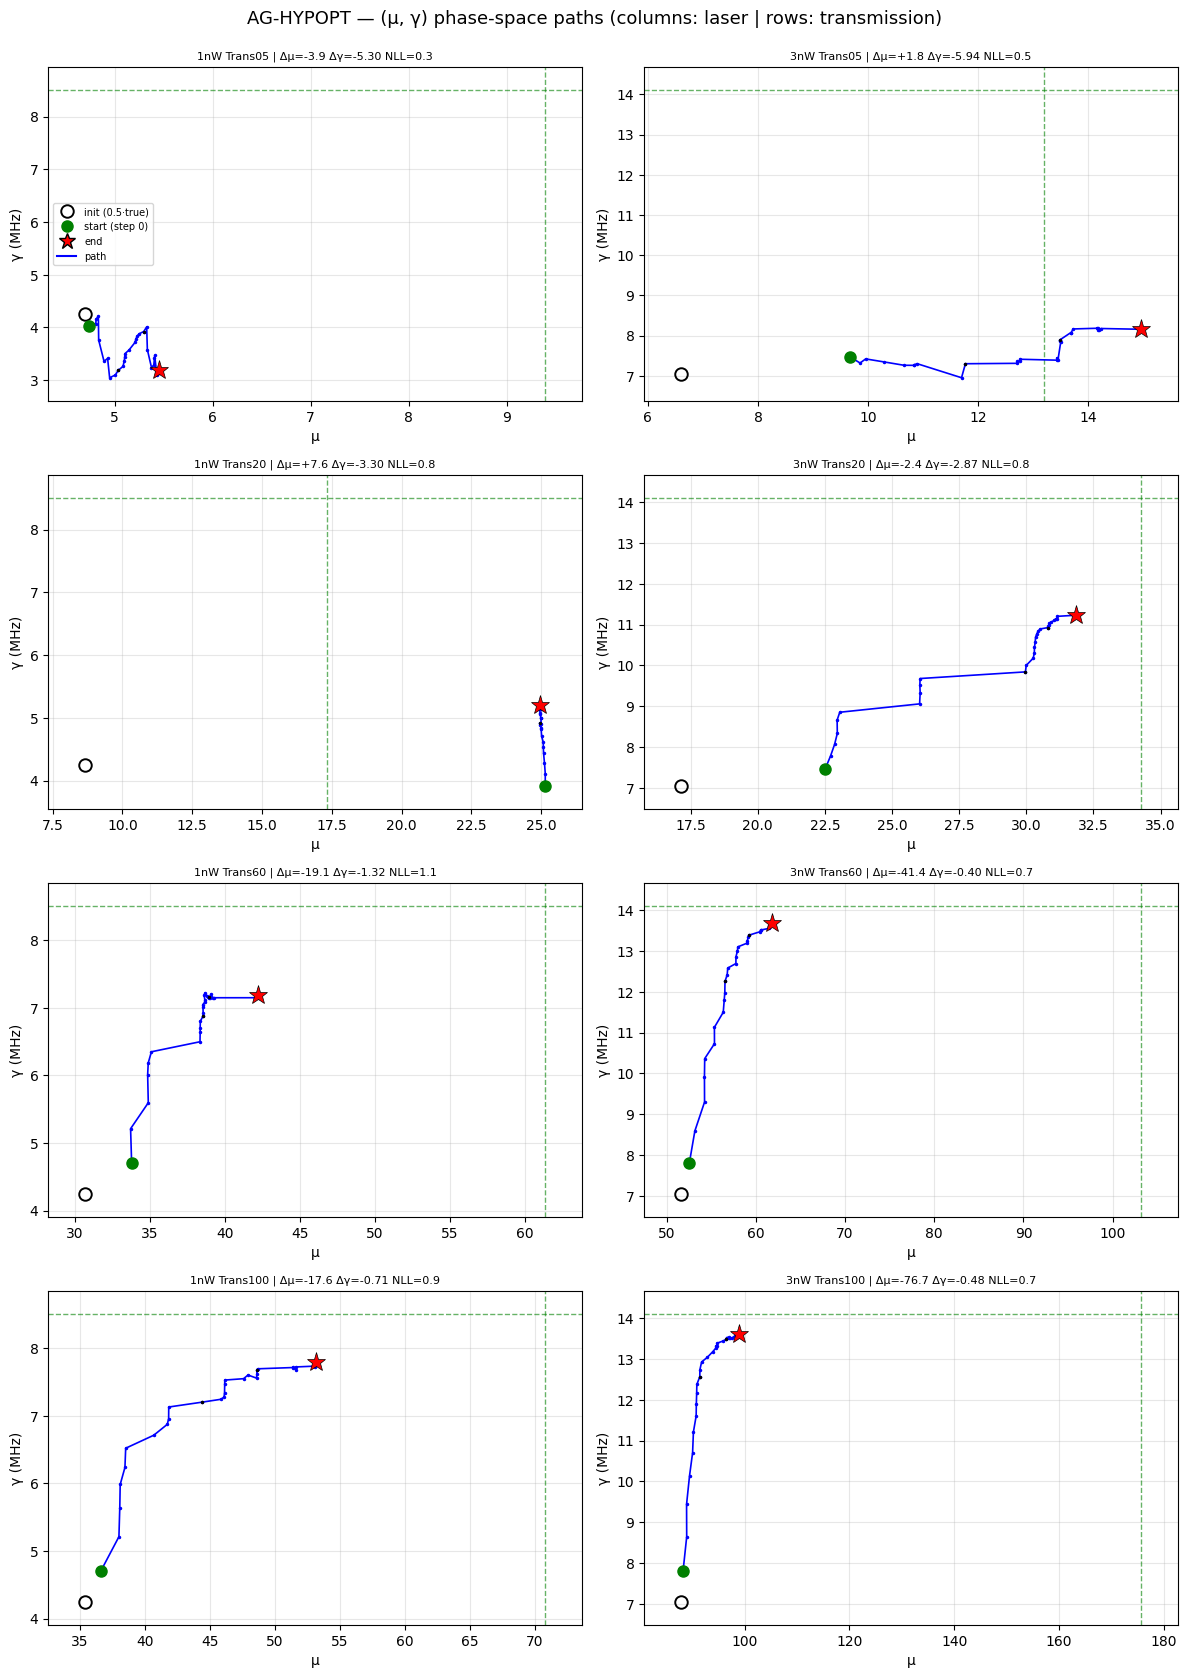

trial finished in 7.8 min
objective = 0.0873 ± 0.0268
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.45   -42.0 |     8.50    3.20   -62.4
1nW Trans20       17.32   24.94   +44.0 |     8.50    5.20   -38.8
1nW Trans60       61.37   42.23   -31.2 |     8.50    7.18   -15.5
1nW Trans100       70.82   53.20   -24.9 |     8.50    7.79    -8.4
3nW Trans05       13.20   14.96   +13.3 |    14.10    8.16   -42.1
3nW Trans20       34.28   31.85    -7.1 |    14.10   11.23   -20.3
3nW Trans60      103.20   61.76   -40.2 |    14.10   13.70    -2.8
3nW Trans100      175.71   99.02   -43.6 |    14.10   13.62    -3.4

weighted objective (T-graded, cap=1.0) = 0.0873 | diverged cells: 0
μ: RMSE 32.324 (rel 33.6%, bias -18.986) | γ: RMSE 3.262 (rel 31.5%, bias -2.540)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

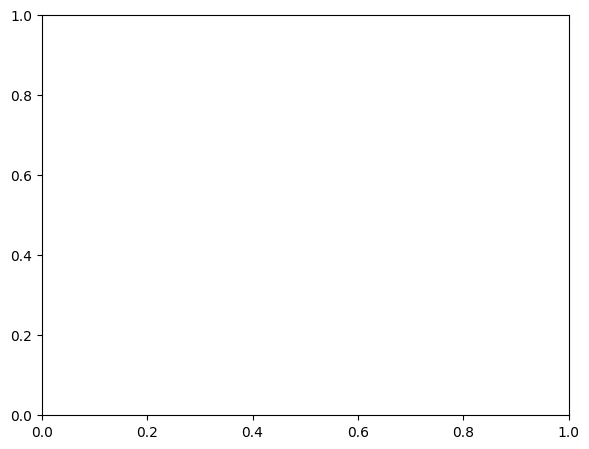

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.0873 ± 0.0268, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
target, h_f_scale = 5.061, h_s_scale = 2.518 - the first campaign point with a low sigma coefficient
(h_s ~2.5, below exp6's 3.675).

Usual pattern: mu undershoots most cells (+44.0 % at 1nW Trans20, +13.3 % at 3nW Trans05), gamma
underestimates all cells (worst 1nW Trans05 -62.4 %). 0.0873 is a mid-to-upper plateau value.

This trial tested the weak trial_09 hint that a smaller sigma coefficient helps, by holding the target rule
and lowering h_s to 2.52. It did NOT improve: 0.0873 versus exp6's 0.0803 at h_s 3.675 and the plateau
centroid ~0.085. So the low-h_s hypothesis is not supported - the plateau is flat in h_s as well, at least
down to h_s ~2.5. Combined with the flatness in h_f, the target-rule objective is noise-limited over the
whole tested plateau, and exp6's 0.0803 is best simply as one draw from that flat cloud.

Execution note: same trailing `plot_parallel` diagnostic TypeError; objective computed and printed first,
so the trial stands. No rerun.

**Summary:** Trial 11 (target rule, h_f 5.061, h_s 2.518) scores objective 0.0873 ± 0.0268, showing the low-sigma-coefficient corner gives no improvement over the plateau.
**Key insight:** Lowering h_s to 2.52 does not improve on exp6's 0.0803, so the target-rule plateau is flat in h_s as well as h_f and the objective there is entirely noise-limited.

Notes for Anuar (optional, not acted on): none new.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 11 (target rule, h_f 5.061, h_s 2.518) scores objective 0.0873 ± 0.0268, showing the low-sigma-coefficient corner gives no improvement over the plateau."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Lowering h_s to 2.52 does not improve on exp6's 0.0803, so the target-rule plateau is flat in h_s as well as h_f and the objective there is entirely noise-limited."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_11 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_12.ipynb. Open it and follow its cells from the top.
